MSE: 0.0005977270690205655
NRMSE: 0.03475902441295928


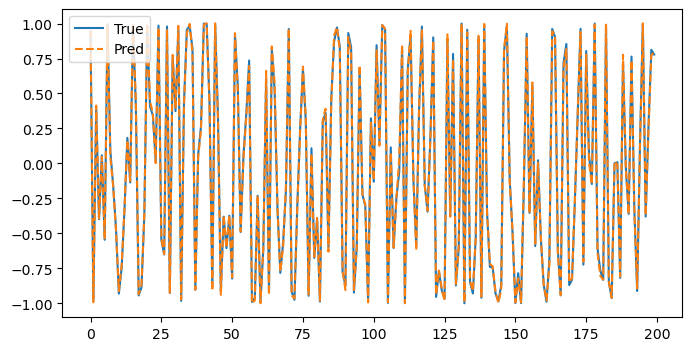

In [7]:
import sys
from pathlib import Path
PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt

from tasks import make_static_sin_task
from encoding_masking import build_masked_input
from Reservoirs.ELM_static import run_elm_static, ELMStaticParams
from readout import split_states_targets, fit_ridge_readout, predict_readout
from metrics import mse, nrmse

# params
L = 2000
N = 50
task_seed = 0
mask_seed = 42
g = 1.0
ridge_alpha = 1e-4
split = 0.8

# task
task = make_static_sin_task(L=L, seed=task_seed)
x, y = task.x, task.y

# encoding/masking
x_norm, mask, V = build_masked_input(x, N=N, rng=mask_seed)

# reservoir
R = run_elm_static(V, ELMStaticParams(g=g))

# readout
s = split_states_targets(R, y, split=split)
model = fit_ridge_readout(s.R_train, s.y_train, alpha=ridge_alpha, fit_intercept=False)
y_pred = predict_readout(model, s.R_test)

# metrics
print("MSE:", mse(s.y_test, y_pred))
print("NRMSE:", nrmse(s.y_test, y_pred))

# plot
plt.figure(figsize=(8,4))
plt.plot(s.y_test[:200], label="True")
plt.plot(y_pred[:200], "--", label="Pred")
plt.legend()
plt.show()